In [1]:
import json

In [5]:
with open('test/input.geojson', 'r') as f:
    data = json.load(f)

In [6]:
data

{'project_boundary': {'type': 'Feature',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[7.671331210498124, 45.066213066884785],
     [7.674764438037698, 45.071426259580136],
     [7.677682681445418, 45.07057763270552],
     [7.673734469776463, 45.06512187335625],
     [7.671331210498124, 45.066213066884785]]]},
  'properties': {}},
 'project_name': 'My Project',
 'save_to_db': True}

## Step 1 — Parse the boundary coordinates

Each coordinate is `[longitude, latitude]`. We extract them and compute the bounding box.

In [7]:
# The list of [lon, lat] pairs that form the polygon outline
coordinates = data["project_boundary"]["geometry"]["coordinates"][0]

print("Number of boundary points:", len(coordinates))
print("First point [lon, lat]:", coordinates[0])

Number of boundary points: 5
First point [lon, lat]: [7.671331210498124, 45.066213066884785]


## Step 2 — Compute the bounding box

Overpass API needs: **south, west, north, east** (= min_lat, min_lon, max_lat, max_lon)

In [8]:
# Separate all longitudes and all latitudes into their own lists
all_longitudes = []
all_latitudes  = []

for point in coordinates:
    lon = point[0]
    lat = point[1]
    all_longitudes.append(lon)
    all_latitudes.append(lat)

# Bounding box corners
south = min(all_latitudes)   # bottom
north = max(all_latitudes)   # top
west  = min(all_longitudes)  # left
east  = max(all_longitudes)  # right

print(f"south = {south}")
print(f"north = {north}")
print(f"west  = {west}")
print(f"east  = {east}")

south = 45.06512187335625
north = 45.071426259580136
west  = 7.671331210498124
east  = 7.677682681445418


## Step 3 — Build the Overpass API query

We ask for all OSM ways tagged with `building=*` inside our bounding box.

In [9]:
overpass_url = "https://overpass-api.de/api/interpreter"

overpass_query = f"""
[out:json];
(
  way["building"]({south},{west},{north},{east});
);
out body;
>;
out skel qt;
"""

print(overpass_query)


[out:json];
(
  way["building"](45.06512187335625,7.671331210498124,45.071426259580136,7.677682681445418);
);
out body;
>;
out skel qt;



## Step 4 — Send the request and get the raw response

In [10]:
import requests

response = requests.get(overpass_url, params={"data": overpass_query})

print("HTTP status:", response.status_code)

osm_data = response.json()

print("Total OSM elements returned:", len(osm_data["elements"]))

HTTP status: 200
Total OSM elements returned: 1363


## Step 5 — Separate nodes and building ways

OSM returns two kinds of elements:
- **node** — a single point with `id`, `lat`, `lon`
- **way**  — an ordered list of node ids that draws the building outline

In [11]:
# Build a dictionary: node_id -> (lon, lat)
# so we can look up any node's coordinates by its id
node_lookup = {}

for element in osm_data["elements"]:
    if element["type"] == "node":
        node_lookup[element["id"]] = (element["lon"], element["lat"])

# Collect only the ways that have a 'building' tag
building_ways = []

for element in osm_data["elements"]:
    if element["type"] == "way":
        if "tags" in element and "building" in element["tags"]:
            building_ways.append(element)

print("Nodes indexed  :", len(node_lookup))
print("Building ways  :", len(building_ways))

Nodes indexed  : 1157
Building ways  : 206


## Step 6 — Convert each building way into a polygon + collect attributes

In [12]:
from shapely.geometry import Polygon

In [21]:


building_records = []

for way in building_ways:

    way_id   = way["id"]
    node_ids = way["nodes"]   # ordered list of node ids
    tags     = way["tags"]

    # Look up the (lon, lat) for each node id in this way
    ring = []
    for nid in node_ids:
        if nid in node_lookup:
            ring.append(node_lookup[nid])

    # Skip if we don't have enough points to form a polygon
    if len(ring) < 3:
        continue

    polygon = Polygon(ring)

    # Fix any minor self-intersection issues
    if not polygon.is_valid:
        polygon = polygon.buffer(0)

    record = {"osm_id": way_id, "geometry": polygon}

    # Add every tag OSM provides as its own column
    for tag_key, tag_value in tags.items():
        record[tag_key] = tag_value

# building_records.append(record)

#     record = {
#         "osm_id":        way_id,
#         "building_type": tags.get("building", "yes"),
#         "name":          tags.get("name", None),
#         "levels":        tags.get("building:levels", None),
#         "geometry":      polygon
#     }

    building_records.append(record)

print("Buildings successfully converted to polygons:", len(building_records))

Buildings successfully converted to polygons: 206


## Step 7 — Create the GeoDataFrame

In [14]:
import geopandas as gpd


In [22]:

buildings_gdf = gpd.GeoDataFrame(building_records, crs="EPSG:4326")

print(buildings_gdf.shape)
buildings_gdf.head()

(206, 56)


,osm_id,geometry,building,castle_type,historic,name,wikidata,wikipedia,building:levels,roof:material,...,layer,area,artist_name,artwork_type,height,length,width,display,support,visibility
0,82105665,"POLYGON ((7.67321 45.07074, 7.67368 45.07082, ...",historic,fortress,castle,Mastio della Cittadella,Q206266,it:Cittadella di Torino,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,166605408,"POLYGON ((7.67154 45.06514, 7.67173 45.06507, ...",yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,180550432,"POLYGON ((7.67002 45.07082, 7.6699 45.07066, 7...",yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,218577295,"POLYGON ((7.67804 45.07076, 7.67819 45.07071, ...",apartments,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,249905839,"POLYGON ((7.67555 45.06485, 7.67542 45.06489, ...",apartments,NaN,NaN,NaN,NaN,NaN,6,roof_tiles,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 8 — (Optional) Keep only buildings that are truly inside the boundary polygon

The bbox query may return buildings that just touch the edge rectangle. This step filters to the exact boundary shape.

In [16]:
from shapely.geometry import shape

In [23]:


# Recreate the boundary as a Shapely polygon
boundary_polygon = shape(data["project_boundary"]["geometry"])

# Make a GeoDataFrame from it (needed for spatial join)
boundary_gdf = gpd.GeoDataFrame(geometry=[boundary_polygon], crs="EPSG:4326")

# Spatial join: keep only buildings that intersect the boundary
buildings_inside = gpd.sjoin(buildings_gdf, boundary_gdf, how="inner", predicate="intersects")

# Remove the extra column added by sjoin
buildings_inside = buildings_inside.drop(columns=["index_right"])
buildings_inside = buildings_inside.reset_index(drop=True)

print("Buildings inside the exact boundary:", len(buildings_inside))
buildings_inside.head()

Buildings inside the exact boundary: 107


,osm_id,geometry,building,castle_type,historic,name,wikidata,wikipedia,building:levels,roof:material,...,layer,area,artist_name,artwork_type,height,length,width,display,support,visibility
0,295695491,"POLYGON ((7.67701 45.07042, 7.6776 45.07021, 7...",apartments,NaN,NaN,NaN,NaN,NaN,5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,295695492,"POLYGON ((7.67683 45.07017, 7.67669 45.06998, ...",yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,300233732,"POLYGON ((7.67555 45.06945, 7.67594 45.06931, ...",apartments,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,318984945,"POLYGON ((7.67472 45.06663, 7.67488 45.06658, ...",apartments,NaN,NaN,NaN,NaN,NaN,5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,318984949,"POLYGON ((7.67501 45.06676, 7.67484 45.06682, ...",yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 9 — Quick plot

In [18]:
import matplotlib.pyplot as plt

/tmp/ipykernel_16774/1346159829.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


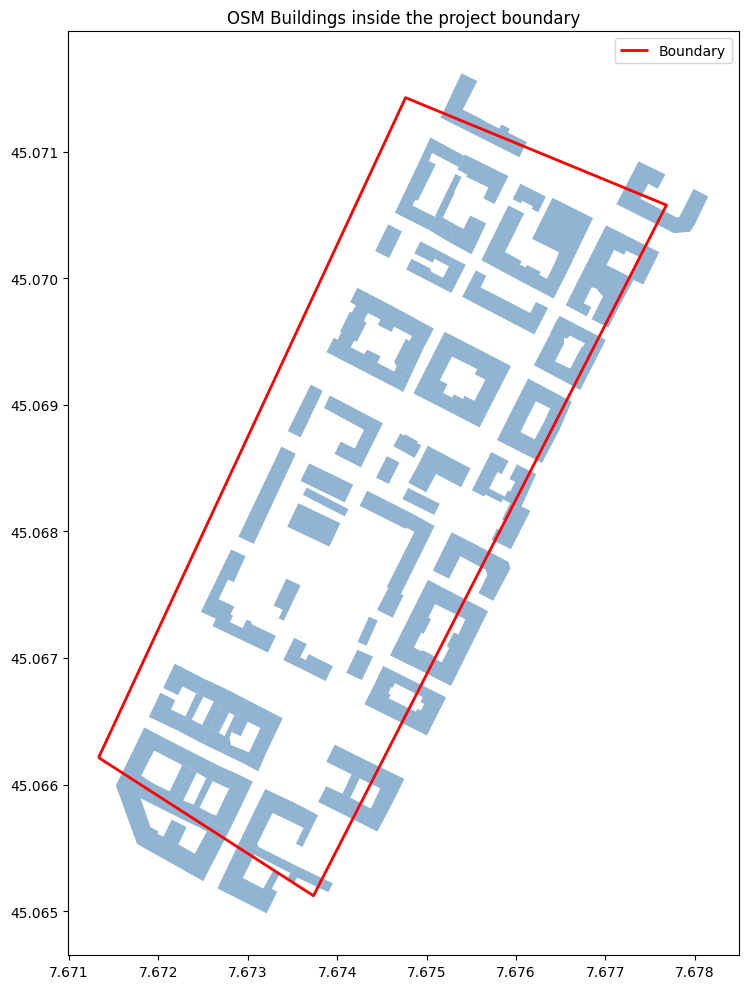

In [24]:


fig, ax = plt.subplots(figsize=(10, 10))

boundary_gdf.boundary.plot(ax=ax, color="red", linewidth=2, label="Boundary")
buildings_inside.plot(ax=ax, color="steelblue", alpha=0.6, label="Buildings")

ax.set_title("OSM Buildings inside the project boundary")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
buildings_inside.iloc[0]


osm_id                                                             295695491
geometry                   POLYGON ((7.6770074 45.0704174, 7.677603 45.07...
building                                                          apartments
castle_type                                                              NaN
historic                                                                 NaN
name                                                                     NaN
wikidata                                                                 NaN
wikipedia                                                                NaN
building:levels                                                            5
roof:material                                                            NaN
roof:shape                                                               NaN
roof:levels                                                                1
amenity                                                                  NaN

---
# Source 2 — BDTRE (Geoportale Piemonte / CSI)

**WFS endpoint:** `https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm`  
**Layer:** `edifc` (Edificio — buildings)  
**Native CRS:** EPSG:32632 (UTM Zone 32N)

| Column | Meaning |
|---|---|
| `uuid` | Unique ID |
| `data_acq` | Acquisition date |
| `data_agg` | Last update date |
| `data_fin` | End-of-validity date |
| `ente_for` | Data supplier |
| `ente_prod` | Producer |
| `modo_prod` | Production method |
| `sc_acq` | Acquisition scale |
| `edifc_ty` | Building type |
| `edifc_uso` | Building use |
| `edifc_stat` | Status (built / demolished) |
| `edifc_mon` | Monument flag |
| `edifc_nome` | Building name |
| `edifc_idag` | Aggregation ID |
| `edifc_ided` | Building ID |

## Step 10 — Convert the boundary bbox from WGS84 to EPSG:32632

BDTRE's WFS only accepts coordinates in its native CRS (UTM Zone 32N).  
We use `pyproj` to convert our lon/lat bbox corners to meters.

In [26]:
from pyproj import Transformer

In [27]:


# Transformer: WGS84 (lon/lat) -> UTM Zone 32N
# always_xy=True means input is always (longitude, latitude)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)

# Convert the two bbox corners (bottom-left and top-right)
x_sw, y_sw = transformer.transform(west, south)   # west, south -> x, y
x_ne, y_ne = transformer.transform(east, north)   # east, north -> x, y

bbox_32632 = f"{x_sw:.0f},{y_sw:.0f},{x_ne:.0f},{y_ne:.0f}"

print("BBOX in EPSG:32632:", bbox_32632)

BBOX in EPSG:32632: 395399,4991043,395911,4991735


## Step 11 — Send the WFS GetFeature request

We request `outputFormat=geojson` so no XML parsing is needed.

In [28]:
bdtre_url = "https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm"

bdtre_response = requests.get(bdtre_url, params={
    "service":      "WFS",
    "version":      "1.0.0",
    "request":      "GetFeature",
    "typeName":     "edifc",
    "BBOX":         bbox_32632,
    "outputFormat": "geojson"
})

print("HTTP status:", bdtre_response.status_code)

bdtre_data = bdtre_response.json()

print("Features returned:", len(bdtre_data["features"]))

HTTP status: 200
Features returned: 192


## Step 12 — Load into a GeoDataFrame

Since the response is already GeoJSON, `geopandas.read_file()` reads it directly —  
all 15 BDTRE attributes are kept automatically, no loops needed.

In [29]:
import json as _json

# read_file() accepts a GeoJSON string directly
bdtre_gdf = gpd.read_file(_json.dumps(bdtre_data))

# The GeoJSON response may already have a CRS — override it with the real native CRS,
# then reproject to WGS84 to match OSM
bdtre_gdf = bdtre_gdf.set_crs("EPSG:32632", allow_override=True)
bdtre_gdf = bdtre_gdf.to_crs("EPSG:4326")

print("Shape:", bdtre_gdf.shape)
print("Columns:", bdtre_gdf.columns.tolist())
bdtre_gdf.head()

## Step 13 — Clip to the exact boundary polygon

In [30]:
# boundary_gdf was already created in the OSM section above
bdtre_buildings = gpd.sjoin(bdtre_gdf, boundary_gdf, how="inner", predicate="intersects")
bdtre_buildings = bdtre_buildings.drop(columns=["index_right"])
bdtre_buildings = bdtre_buildings.reset_index(drop=True)

print("BDTRE buildings inside boundary:", len(bdtre_buildings))
bdtre_buildings.head()

BDTRE buildings inside boundary: 95


,uuid,data_acq,data_agg,data_fin,ente_for,ente_prod,modo_prod,sc_acq,edifc_ty,edifc_uso,edifc_stat,edifc_mon,edifc_nome,edifc_idag,edifc_ided,geometry
0,0c50c9e2-e91c-4872-adc0-bed7b02ff6f4,2010-01-01,2022-12-31,9999/12/31 00:00:00,REGIONE PIEMONTE,CSI PIEMONTE,rilievo speditivo - ortofoto,1:10000,generica,"teatro, auditorium",costruito,0,Teatro Alfieri,,,"POLYGON ((7.67716 45.06979, 7.67717 45.06981, ..."
1,f0defafb-4400-49f4-9726-099d22fb980b,2019-11-30,2019-11-30,9999/12/31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,"POLYGON ((7.67679 45.06927, 7.67683 45.06933, ..."
2,f7a902dd-ecff-414e-82e5-2a8ba0e3f128,2019-11-30,2019-11-30,9999/12/31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,"POLYGON ((7.67514 45.07021, 7.6751 45.07016, 7..."
3,1326d0e6-f3e2-4c66-b2ed-b6603232d1f0,2019-11-30,2019-11-30,9999/12/31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,"POLYGON ((7.67536 45.07087, 7.67535 45.07086, ..."
4,e89fd04e-0d0d-4964-8499-7da94540455a,2010-01-01,2022-12-31,9999/12/31 00:00:00,REGIONE PIEMONTE,CSI PIEMONTE,rilievo speditivo - ortofoto,1:10000,generica,residenziale e commerciale,costruito,0,,,,"POLYGON ((7.6773 45.06999, 7.67741 45.06995, 7..."


---
# Compare OSM vs BDTRE side by side

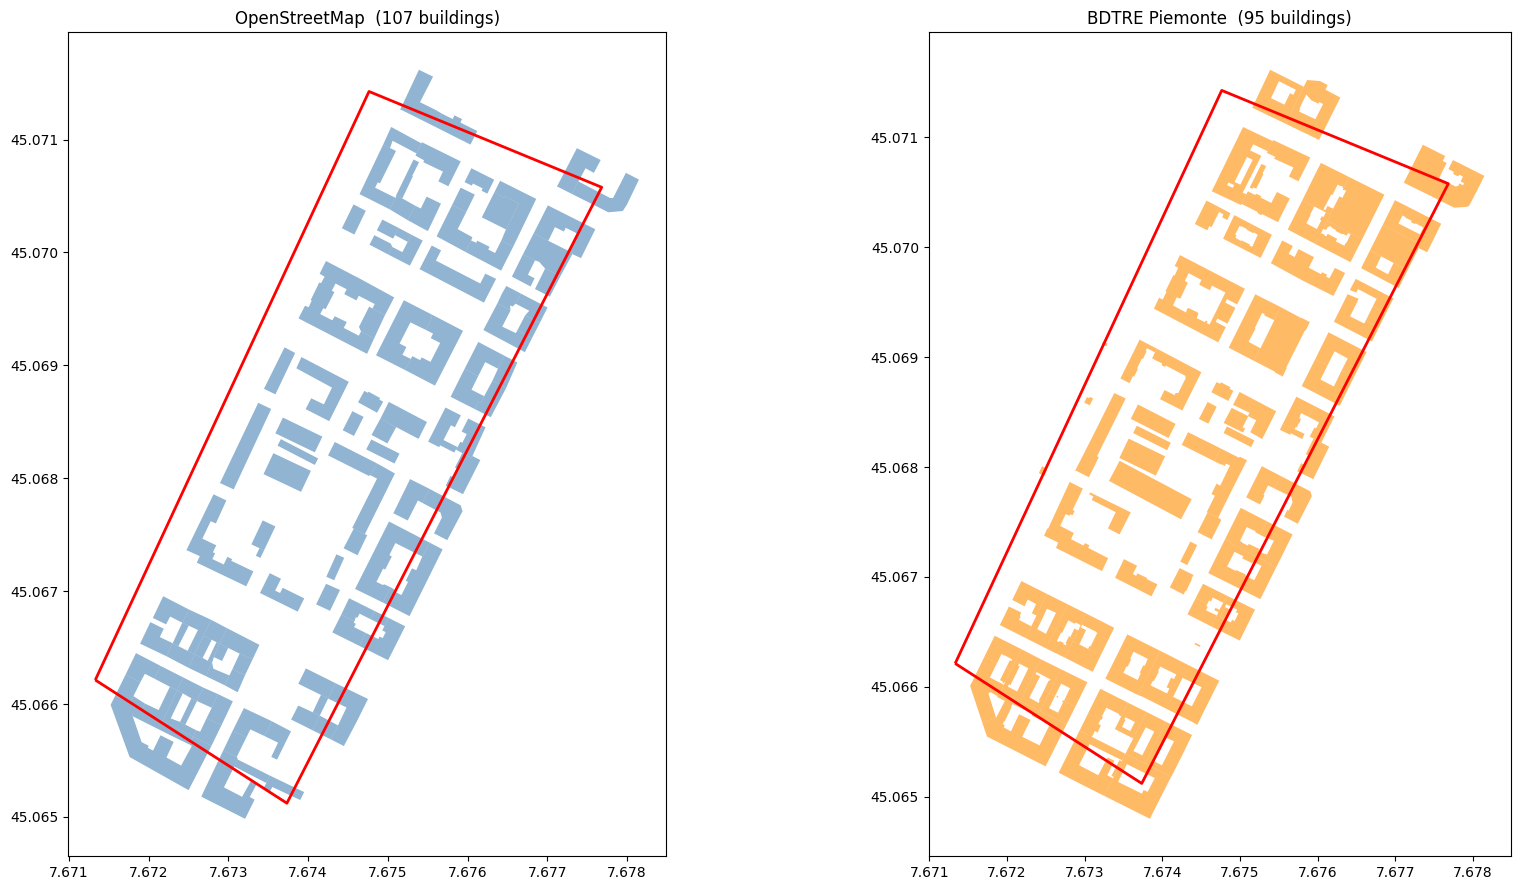

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- OSM ---
ax1 = axes[0]
boundary_gdf.boundary.plot(ax=ax1, color="red", linewidth=2)
buildings_inside.plot(ax=ax1, color="steelblue", alpha=0.6)
ax1.set_title(f"OpenStreetMap  ({len(buildings_inside)} buildings)")

# --- BDTRE ---
ax2 = axes[1]
boundary_gdf.boundary.plot(ax=ax2, color="red", linewidth=2)
bdtre_buildings.plot(ax=ax2, color="darkorange", alpha=0.6)
ax2.set_title(f"BDTRE Piemonte  ({len(bdtre_buildings)} buildings)")

plt.tight_layout()
plt.show()

In [32]:
bdtre_buildings.iloc[0]

uuid                       0c50c9e2-e91c-4872-adc0-bed7b02ff6f4
data_acq                                    2010-01-01 00:00:00
data_agg                                    2022-12-31 00:00:00
data_fin                                    9999/12/31 00:00:00
ente_for                                       REGIONE PIEMONTE
ente_prod                                          CSI PIEMONTE
modo_prod                          rilievo speditivo - ortofoto
sc_acq                                                  1:10000
edifc_ty                                               generica
edifc_uso                                    teatro, auditorium
edifc_stat                                            costruito
edifc_mon                                                     0
edifc_nome                                       Teatro Alfieri
edifc_idag                                                     
edifc_ided                                                     
geometry      POLYGON ((7.67715710957826

---
# Source 3 — DBGT (Comune di Torino)

**WFS endpoint:** `https://geomap.reteunitaria.piemonte.it/ws/siccms/coto-01/wfsg01/wfs_sicc140_edificato_dbgt`  
**Layer:** `Edificato`  
**Native CRS:** EPSG:3003 (Gauss-Boaga West)

This is the best source for the three attributes we need:

| Column | Meaning | Example values |
|---|---|---|
| `altezza_edificio` | Building height in meters | `"7.73"`, `"3.35"` |
| `categoria_uso` | Usage type | `"residenziale"`, `"commerciale - terziario"`, `"militare"`, `"servizio pubblico"` |
| `epoca_costruzione` | Construction period | `"1946 - 1960"`, `"2017"`, `"non conosciuto"` |
| `numero_piani` | Number of floors | `"5"`, `"2"` |
| `valenza_storica` | Historical significance | `"monumentale"`, `"non monumentale"` |
| `qt_gronda` | Eave elevation (m a.s.l.) | `"247.20"` |
| `qt_suolo` | Ground elevation (m a.s.l.) | `"239.47"` |

## Step 14 — Convert the boundary bbox to EPSG:3003

DBGT uses **EPSG:3003** (Gauss-Boaga West), different from BDTRE's UTM 32N.

In [ ]:
from pyproj import Transformer

In [33]:


# WGS84 -> Gauss-Boaga West
transformer_3003 = Transformer.from_crs("EPSG:4326", "EPSG:3003", always_xy=True)

x_sw_3003, y_sw_3003 = transformer_3003.transform(west, south)
x_ne_3003, y_ne_3003 = transformer_3003.transform(east, north)

bbox_3003 = f"{x_sw_3003:.0f},{y_sw_3003:.0f},{x_ne_3003:.0f},{y_ne_3003:.0f}"

print("BBOX in EPSG:3003:", bbox_3003)

BBOX in EPSG:3003: 1395425,4991063,1395936,4991755


## Step 15 — Fetch from DBGT WFS

In [34]:
dbgt_url = "https://geomap.reteunitaria.piemonte.it/ws/siccms/coto-01/wfsg01/wfs_sicc140_edificato_dbgt"

dbgt_response = requests.get(dbgt_url, params={
    "service":      "WFS",
    "version":      "1.0.0",
    "request":      "GetFeature",
    "typeName":     "Edificato",
    "BBOX":         bbox_3003,
    "outputFormat": "geojson"
})

print("HTTP status:", dbgt_response.status_code)

dbgt_data = dbgt_response.json()

print("Features returned:", len(dbgt_data["features"]))

HTTP status: 200
Features returned: 523


## Step 16 — Load into a GeoDataFrame and reproject to WGS84

In [ ]:
import json as _json


In [37]:


dbgt_gdf = gpd.read_file(_json.dumps(dbgt_data))

# The GeoJSON response may already have a CRS — override it with the real native CRS,
# then reproject to WGS84
dbgt_gdf = dbgt_gdf.set_crs("EPSG:3003", allow_override=True)
dbgt_gdf = dbgt_gdf.to_crs("EPSG:4326")

print("Shape:", dbgt_gdf.shape)
print("Columns:", dbgt_gdf.columns.tolist())
dbgt_gdf.head()

Shape: (523, 13)
Columns: ['codice_intesa', 'gruppo', 'descrizione', 'categoria_uso', 'epoca_costruzione', 'numero_piani', 'altezza_edificio', 'valenza_storica', 'nome', 'qt_gronda', 'qt_suolo', 'transito', 'geometry']


,codice_intesa,gruppo,descrizione,categoria_uso,epoca_costruzione,numero_piani,altezza_edificio,valenza_storica,nome,qt_gronda,qt_suolo,transito,geometry
0,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,,1918 (al ..),,,,,,241.17,,"POLYGON ((7.67289 45.06656, 7.67287 45.06657, ..."
1,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,,non conosciuto,,4.26,,,247.46,243.20,,"POLYGON ((7.67285 45.07051, 7.67272 45.07055, ..."
2,020106,EDIFICI MINORI (O DI PERTINENZA),"garage, box auto",,non conosciuto,,3.35,,,245.55,242.20,,"POLYGON ((7.67179 45.06783, 7.67182 45.06787, ..."
3,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,,1918 (al ..),,4.98,,,246.53,241.55,,"POLYGON ((7.67245 45.06672, 7.67241 45.06667, ..."
4,020106,EDIFICI MINORI (O DI PERTINENZA),portico non sovracostruito,,1919 - 1945,,6.67,non monumentale,,245.13,238.46,,"POLYGON ((7.67706 45.06526, 7.67685 45.06497, ..."


## Step 17 — Clip to the exact boundary and inspect the key columns

In [38]:
dbgt_buildings = gpd.sjoin(dbgt_gdf, boundary_gdf, how="inner", predicate="intersects")
dbgt_buildings = dbgt_buildings.drop(columns=["index_right"])
dbgt_buildings = dbgt_buildings.reset_index(drop=True)

print("DBGT buildings inside boundary:", len(dbgt_buildings))

# Show only the three columns we care about
dbgt_buildings[["altezza_edificio", "categoria_uso", "epoca_costruzione", "numero_piani", "nome"]].head(15)

DBGT buildings inside boundary: 271


,altezza_edificio,categoria_uso,epoca_costruzione,numero_piani,nome
0,,,1918 (al ..),,
1,4.98,,1918 (al ..),,
2,,,1918 (al ..),,
3,2.21,,non conosciuto,,
4,6.5,,non conosciuto,,
5,3.4,,2017,,
6,,,1919 - 1945,,
7,3.25,,2017,,
8,3.59,,1946 - 1960,,
9,,,non conosciuto,,


## Step 18 — Check unique usage types and construction periods in the dataset

In [39]:
print("=== categoria_uso (usage types) ===")
print(dbgt_buildings["categoria_uso"].value_counts(dropna=False))

print()
print("=== epoca_costruzione (construction periods) ===")
print(dbgt_buildings["epoca_costruzione"].value_counts(dropna=False))

=== categoria_uso (usage types) ===
categoria_uso
residenziale                                         129
                                                      70
militare                                              25
amministrativo                                        15
servizio pubblico                                     12
commerciale - terziario                               11
commerciale                                            3
servizi - istruzione - sede di scuola                  2
non conosciuto                                         2
servizi trasporto-parcheggio multipiano o coperto      1
ricreativo - teatro, auditorium                        1
Name: count, dtype: int64

=== epoca_costruzione (construction periods) ===
epoca_costruzione
1918 (al ..)      102
non conosciuto     98
1919 - 1945        37
1946 - 1960        28
2017                3
1961 - 1970         2
2015                1
Name: count, dtype: int64


## Step 19 — Plot DBGT buildings coloured by usage type

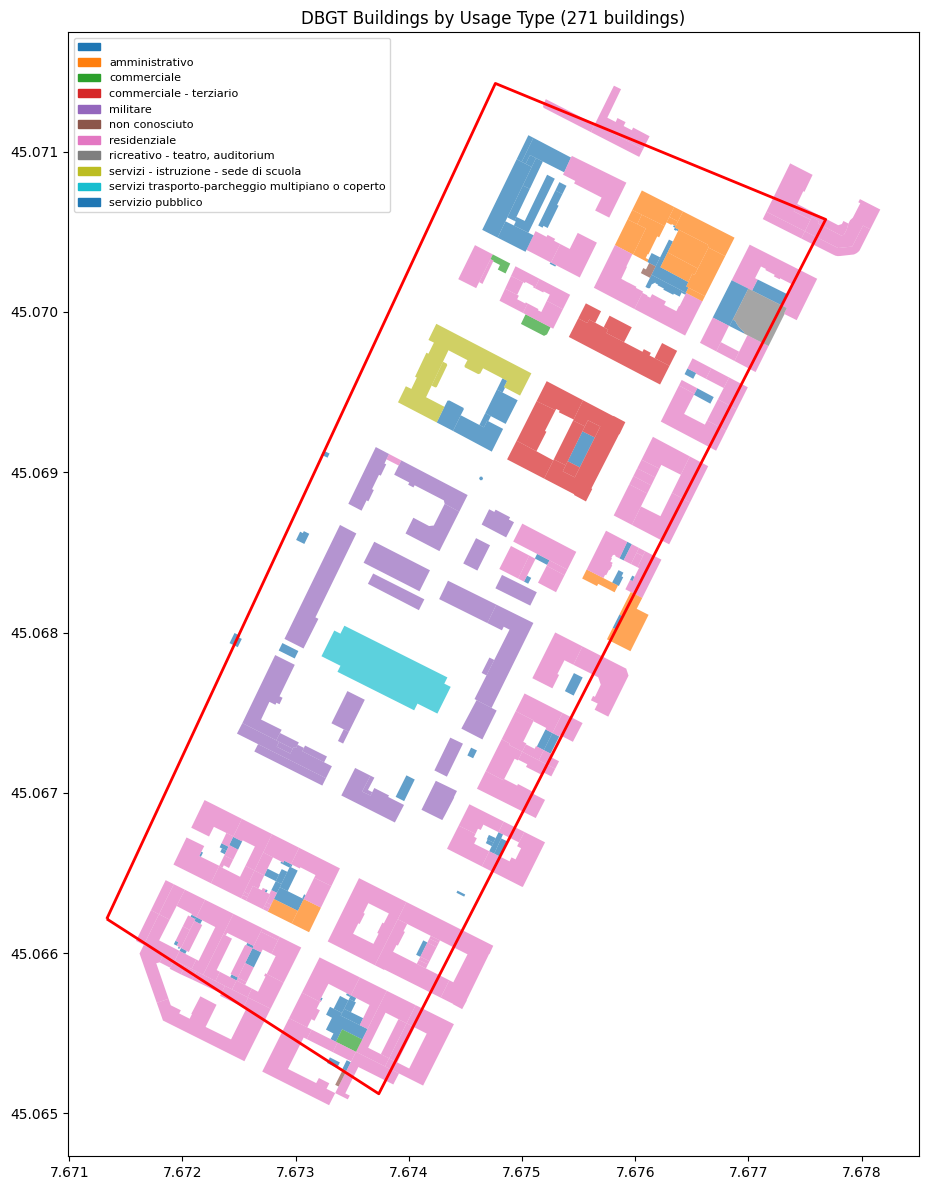

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Assign a colour to each unique usage type
usage_types = dbgt_buildings["categoria_uso"].fillna("non classificato").unique()

color_palette = plt.cm.tab10.colors

color_map = {}
for i, usage in enumerate(sorted(usage_types)):
    color_map[usage] = color_palette[i % len(color_palette)]

# Assign colour column
dbgt_buildings["color"] = dbgt_buildings["categoria_uso"].fillna("non classificato").map(color_map)

fig, ax = plt.subplots(figsize=(12, 12))

dbgt_buildings.plot(ax=ax, color=dbgt_buildings["color"], alpha=0.7)
boundary_gdf.boundary.plot(ax=ax, color="red", linewidth=2)

# Legend
patches = [mpatches.Patch(color=color_map[u], label=u) for u in sorted(color_map)]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title(f"DBGT Buildings by Usage Type ({len(dbgt_buildings)} buildings)")

plt.tight_layout()
plt.show()

---
# Building GDF Strategy — Multi-Source Conflation

---

## The Core Challenge: Geometry Mismatch Types

When you overlay two sources, buildings fall into 5 relationship types:

| Source A (DBGT) | Source B (OSM) | Relationship |
|---|---|---|
| building 1 | building 1 | **1:1** — same footprint (easy) |
| building 2 | b2a + b2b | **1:N** — OSM split it |
| b3a + b3b | building 3 | **N:1** — OSM merged them |
| building 4 | *(missing)* | **1:0** — not in OSM |
| *(missing)* | building 5 | **0:1** — not in DBGT |

Each case needs a different resolution strategy.

---

## Proposed Architecture

```
┌──────────────────────────────────────────────┐
│              RAW DATA LAYER                  │
│   OSM  │  BDTRE  │  DBGT  │  user_upload    │
└─────────────────┬────────────────────────────┘
                  │
                  ▼
┌──────────────────────────────────────────────┐
│              NORMALIZER                      │
│  Maps every source's columns → standard      │
│  schema: height, usage, year, floors,        │
│  footprint, source_name, source_confidence   │
└─────────────────┬────────────────────────────┘
                  │
                  ▼
┌──────────────────────────────────────────────┐
│         GEOMETRY AUTHORITY PICKER            │
│  Pick ONE source as the geometric truth.     │
│  Priority: user > DBGT > BDTRE > OSM        │
│  (official cadastral beats crowdsourced)     │
└─────────────────┬────────────────────────────┘
                  │
                  ▼
┌──────────────────────────────────────────────┐
│            SPATIAL MATCHER                   │
│  For each authority building, find           │
│  overlapping polygons in other sources       │
│  using IoU (Intersection over Union):        │
│                                              │
│  IoU > 0.5  →  same building  (1:1)         │
│  1 → many   →  aggregation    (1:N)         │
│  many → 1   →  subdivision    (N:1)         │
│  no match   →  unique source  (1:0 / 0:1)  │
└─────────────────┬────────────────────────────┘
                  │
                  ▼
┌──────────────────────────────────────────────┐
│           ATTRIBUTE RESOLVER                 │
│  Per attribute, apply priority + fallback:   │
│                                              │
│  height  → user > DBGT > BDTRE > OSM        │
│  usage   → user > DBGT > BDTRE > OSM        │
│  year    → user > DBGT > OSM                │
│  floors  → user > DBGT > OSM > height÷3     │
│                                              │
│  1:N → authority attributes → all children  │
│  N:1 → keep N geometries, copy 1 attribute  │
└─────────────────┬────────────────────────────┘
                  │
                  ▼
┌──────────────────────────────────────────────┐
│            FINAL building_gdf                │
│  geometry │ height │ usage │ year │ floors   │
│  + provenance columns per attribute          │
│    (height_source, usage_source, ...)        │
└──────────────────────────────────────────────┘
```

---

## Normalizer — Standard Schema

Every source gets mapped to the same column names before any matching:

```python
STANDARD_SCHEMA = {
    "height":  float,   # meters
    "usage":   str,     # 'residential', 'commercial', 'mixed', 'unknown'
    "year":    str,     # '1946-1960' or '1972' or None
    "floors":  int,
    "name":    str,
    "source":  str,     # 'dbgt', 'bdtre', 'osm', 'user'
}

COLUMN_MAP = {
    "dbgt":  { "height": "altezza_edificio",
               "usage":  "categoria_uso",
               "year":   "epoca_costruzione",
               "floors": "numero_piani" },

    "bdtre": { "height": None,          # lives in un_vol layer
               "usage":  "edifc_uso",
               "year":   None },

    "osm":   { "height": "height",
               "usage":  "building",
               "year":   None,
               "floors": "building:levels" },
}
```

---

## Spatial Matching — IoU Logic

```
iou = area(A ∩ B) / area(A ∪ B)

iou > 0.5        →  1:1 match   — merge attributes directly
1 A, many B      →  1:N         — copy A's attributes to all B polygons
many A, 1 B      →  N:1         — keep A geometries, copy B attribute to each
no overlap       →  unmatched   — keep building, mark missing attrs as None
```

**N:1 case** (OSM merged what DBGT shows as separate buildings):  
Keep DBGT's finer geometries. Assign the single OSM/BDTRE attribute value to all of them.

**1:N case** (OSM split what DBGT shows as one building):  
Keep the authority geometry (DBGT). Discard OSM sub-polygons. Pull useful OSM attributes.

---

## Key Decisions Before Implementation

| Decision | Options |
|---|---|
| Which source owns the geometry? | Fixed priority, or user chooses per project |
| IoU threshold | 0.5 standard — may need 0.3 for imprecise cadastral data |
| Attribute conflict resolution | Priority chain, or flag as conflict for manual review |
| Buildings unique to non-authority source | Include as `source='osm_only'`, or discard |
| Store provenance? | Yes — `height_source`, `usage_source` per row |

---

## Recommended First Implementation (incremental)

Don't solve all cases at once. Build in layers:

1. **Normalizer only** — get all sources into the standard schema
2. **DBGT as geometry authority** — richest single source (height + usage + year)
3. **Fill DBGT gaps from OSM** — centroid-in-polygon lookup for missing attributes
4. **Flag unmatched buildings** — OSM/BDTRE buildings with no DBGT overlap → `source='osm_only'`
5. **Add IoU matcher later** — once step 1–4 work end-to-end
